In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Experience_Salary.xlsx to Experience_Salary.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_excel('Experience_Salary.xlsx')  # Replace with your file name
print(df.head())

   Experience_Years  Salary_USD
0                 1       35000
1                 2       37000
2                 3       39000
3                 4       42000
4                 5       45000


In [ ]:
X = df['Experience_Years']
Y = df['Salary_USD']


In [ ]:
x_squre=X.copy()
x_squre=x_squre*x_squre
x_squre

,Experience_Years
0,1
1,4
2,9
3,16
4,25
5,36
6,49
7,64
8,81
9,100


In [ ]:
XY = X.copy()
XY = XY * Y
(XY)


,0
0,35000
1,74000
2,117000
3,168000
4,225000
5,288000
6,350000
7,424000
8,504000
9,590000


In [ ]:
df["x_squre"]=x_squre
df["XY"]=XY

In [ ]:
df

,Experience_Years,Salary_USD,x_squre,XY
0,1,35000,1,35000
1,2,37000,4,74000
2,3,39000,9,117000
3,4,42000,16,168000
4,5,45000,25,225000
5,6,48000,36,288000
6,7,50000,49,350000
7,8,53000,64,424000
8,9,56000,81,504000
9,10,59000,100,590000


In [ ]:
sum_xy=df["XY"].sum()
sum_xy

np.int64(7196000)

In [ ]:
X=sm.add_constant(X)
Y=df["Salary_USD"]

In [ ]:
model=sm.OLS(Y,X).fit()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Salary_USD   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     9821.
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           4.21e-20
Time:                        07:37:18   Log-Likelihood:                -112.51
No. Observations:                  15   AIC:                             229.0
Df Residuals:                      13   BIC:                             230.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             3.118e+04    255.578  

In [ ]:
pred=model.get_prediction(X)
confident_val=0.95
alpha=1-confident_val
conf_init=pred.conf_int(alpha=alpha)
predicted=model.predict(X)

In [ ]:
conf_init

array([[33467.123078  , 34466.21025534],
       [36303.37996659, 37201.38193818],
       [39136.80276092, 39939.38771527],
       [41966.25519513, 42681.36385249],
       [44790.10210956, 45428.94550949],
       [47606.11696908, 48184.35922139],
       [50411.6430653 , 50950.2616966 ],
       [53204.29351992, 53729.03981341],
       [55983.07163673, 56521.69026803],
       [58748.97411194, 59327.21636425],
       [61504.38782384, 62143.23122378],
       [64251.96948084, 64967.07813821],
       [66993.94561806, 67796.53057241],
       [69731.95139516, 70629.95336675],
       [72467.123078  , 73466.21025534]])

In [ ]:
result=df.copy()
result["predicted"]=predicted
result["Lower_CI"]=conf_init[:,0]
result["Upper_CI"]=conf_init[:,1]
result

,Experience_Years,Salary_USD,x_squre,XY,predicted,Lower_CI,Upper_CI
0,1,35000,1,35000,33966.666667,33467.123078,34466.210255
1,2,37000,4,74000,36752.380952,36303.379967,37201.381938
2,3,39000,9,117000,39538.095238,39136.802761,39939.387715
3,4,42000,16,168000,42323.809524,41966.255195,42681.363852
4,5,45000,25,225000,45109.523810,44790.102110,45428.945509
5,6,48000,36,288000,47895.238095,47606.116969,48184.359221
6,7,50000,49,350000,50680.952381,50411.643065,50950.261697
7,8,53000,64,424000,53466.666667,53204.293520,53729.039813
8,9,56000,81,504000,56252.380952,55983.071637,56521.690268
9,10,59000,100,590000,59038.095238,58748.974112,59327.216364


In [ ]:
print(result.head())


   Experience_Years  Salary_USD  x_squre      XY     predicted      Lower_CI  \
0                 1       35000        1   35000  33966.666667  33467.123078   
1                 2       37000        4   74000  36752.380952  36303.379967   
2                 3       39000        9  117000  39538.095238  39136.802761   
3                 4       42000       16  168000  42323.809524  41966.255195   
4                 5       45000       25  225000  45109.523810  44790.102110   

       Upper_CI  
0  34466.210255  
1  37201.381938  
2  39939.387715  
3  42681.363852  
4  45428.945509  


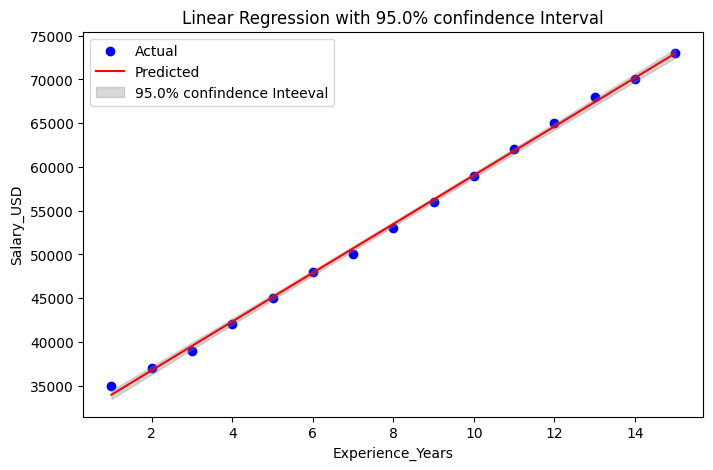

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Experience_Years"],df["Salary_USD"], color='blue', label="Actual")
plt.plot(df["Experience_Years"], predicted, color="red", label="Predicted")
plt.fill_between(df["Experience_Years"], result["Lower_CI"], result["Upper_CI"], color="gray", alpha=0.3, label=f"{confident_val*100}% confindence Inteeval")
plt.xlabel("Experience_Years")
plt.ylabel("Salary_USD")
plt.title(f"Linear Regression with {confident_val*100}% confindence Interval")
plt.legend()
plt.show()